#  Eigenvalues and Eigenvectors

**After this assignment you will be able to:**
- use Python to find eigenvalues and eigenvectors
- visualize and interpret eigenvalues and eigenvectos
- apply linear transformations, eigenvalues and eigenvectors in a webpage navigation model

# Table of Contents
- [ 1 - Eigenvalues and Eigenvectors: Definition and Interpretation](#1)
  - [ 1.1 - Definition of Eigenvalues and Eigenvectors](#1.1)
  - [ 1.2 - Finding Eigenvalues and Eigenvectors with Python](#1.2)

## Packages

Run the following cell to load the packages you'll need.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<a name='1'></a>
## 1 - Eigenvalues and Eigenvectors: Definition and Interpretation

<a name='1.1'></a>
### 1.1 - Definition of Eigenvalues and Eigenvectors

Let's consider a linear transformation defined by matrix $A=\begin{bmatrix}2 & 3 \\ 2 & 1 \end{bmatrix}$.

Apply this transformation to the standard basis vectors $e_1=\begin{bmatrix}1 \\ 0\end{bmatrix}$ and $e_2=\begin{bmatrix}0 \\ 1\end{bmatrix}$

and visualize the result (this was covered in details in the previous labs of this Course):

In [2]:
A = np.array([[2, 3],[2, 1]])
e1 = np.array([[1],[0]])
e2 = np.array([[0],[1]])

In [3]:
A@e1

array([[2],
       [2]])

In [4]:
A@e2

array([[3],
       [1]])

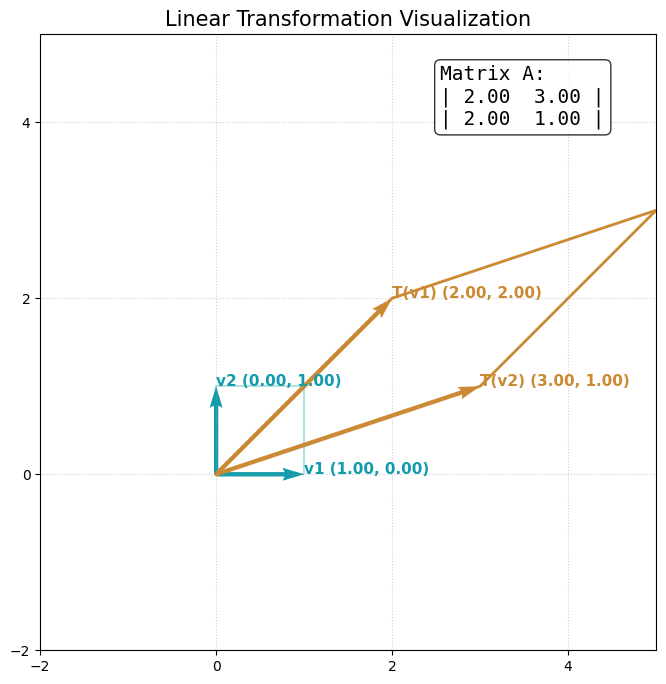

In [24]:
def plot_transformation(T, v1, v2):
    color_original = "#129cab"
    color_transformed = "#cc8933"

    fig, ax = plt.subplots(figsize=(8, 8))

    # Grid and Axis Settings
    ax.set_xticks(np.arange(-10, 11, 2))
    ax.set_yticks(np.arange(-10, 11, 2))
    ax.axis([-2, 5, -2, 5])
    ax.grid(True, linestyle=':', alpha=0.6)

    # 1. Original Vectors
    ax.quiver([0, 0], [0, 0], [v1[0,0], v2[0,0]], [v1[1,0], v2[1,0]],
              color=color_original, angles='xy', scale_units='xy', scale=1, width=0.007)
    ax.plot([0, v2[0,0], v1[0,0]+v2[0,0], v1[0,0], 0],
            [0, v2[1,0], v1[1,0]+v2[1,0], v1[1,0], 0], color=color_original, alpha=0.3)

    # :.2f 를 사용하여 소수점 2째 자리까지만 출력
    ax.text(v1[0,0], v1[1,0], f'v1 ({v1[0,0]:.2f}, {v1[1,0]:.2f})',
            fontsize=11, color=color_original, fontweight='bold')
    ax.text(v2[0,0], v2[1,0], f'v2 ({v2[0,0]:.2f}, {v2[1,0]:.2f})',
            fontsize=11, color=color_original, fontweight='bold')

    # 2. Transformed Vectors
    v1_transformed = T @ v1
    v2_transformed = T @ v2

    ax.quiver([0, 0], [0, 0], [v1_transformed[0,0], v2_transformed[0,0]], [v1_transformed[1,0], v2_transformed[1,0]],
               color=color_transformed, angles='xy', scale_units='xy', scale=1, width=0.007)
    ax.plot([0, v2_transformed[0,0], v1_transformed[0,0]+v2_transformed[0,0], v1_transformed[0,0], 0],
             [0, v2_transformed[1,0], v1_transformed[1,0]+v2_transformed[1,0], v1_transformed[1,0], 0],
             color=color_transformed, linewidth=2)

    # :.2f 를 사용하여 변환된 좌표도 깔끔하게 정리
    ax.text(v1_transformed[0,0], v1_transformed[1,0],
            f'T(v1) ({v1_transformed[0,0]:.2f}, {v1_transformed[1,0]:.2f})',
            fontsize=11, color=color_transformed, fontweight='bold')
    ax.text(v2_transformed[0,0], v2_transformed[1,0],
            f'T(v2) ({v2_transformed[0,0]:.2f}, {v2_transformed[1,0]:.2f})',
            fontsize=11, color=color_transformed, fontweight='bold')

    # 3. Matrix A Display
    matrix_info = f"Matrix A:\n| {T[0,0]:.2f}  {T[0,1]:.2f} |\n| {T[1,0]:.2f}  {T[1,1]:.2f} |"
    ax.text(0.65, 0.95, matrix_info, transform=ax.transAxes,
            fontsize=14, family='monospace', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_aspect("equal")
    plt.title("Linear Transformation Visualization", fontsize=15)

    plt.show()
    plt.close(fig)

plot_transformation(A, e1, e2)

### **plot_transformation(A, e1, e2) 은  e1, e2 벡터를 A 행렬이 선형변환하여 시각화해주는 함수**

$A$: $2 \times 2$ 행렬 $\begin{pmatrix} 2 & 3 \\ 2 & 1 \end{pmatrix}$$e_1$: $2 \times 1$ 열 벡터 $\begin{pmatrix} 1 \\ 0 \end{pmatrix}$$e_2$: $2 \times 1$ 열 벡터 $\begin{pmatrix} 0 \\ 1 \end{pmatrix}$

In [7]:
print(A, A.shape)
print('\n')
print(e1, e1.shape)
print('\n')
print(e2, e2.shape)

[[2 3]
 [2 1]] (2, 2)


[[1]
 [0]] (2, 1)


[[0]
 [1]] (2, 1)


1. $A @ e_1$ (행렬 $A$와 $e_1$의 곱)이 계산은 행렬 $A$의 첫 번째 열을 추출하는 것과 같습니다.$$A e_1 = \begin{pmatrix} 2 & 3 \\ 2 & 1 \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} 2 \cdot 1 + 3 \cdot 0 \\ 2 \cdot 1 + 1 \cdot 0 \end{pmatrix} = \begin{pmatrix} 2 \\ 2 \end{pmatrix}$$

In [ ]:
A@e1  # (2x2) @ (2,1)

array([[2],
       [2]])

2. $A @ e_2$ (행렬 $A$와 $e_2$의 곱)이 계산은 행렬 $A$의 두 번째 열을 추출하는 것과 같습니다.$$A e_2 = \begin{pmatrix} 2 & 3 \\ 2 & 1 \end{pmatrix} \begin{pmatrix} 0 \\ 1 \end{pmatrix} = \begin{pmatrix} 2 \cdot 0 + 3 \cdot 1 \\ 2 \cdot 0 + 1 \cdot 1 \end{pmatrix} = \begin{pmatrix} 3 \\ 1 \end{pmatrix}$$

In [ ]:
A@e2

array([[3],
       [1]])

Both of the original basis vectors $e_1$ and $e_2$ (shown as $v_1$ and $v_2$ on the plot) changed their length and direction with the transformation $A$.

What if you can choose some other basis vectors, where only their length will change?

For the vector $v$, its transformation will be $Av=\lambda v$.

Vector $v$ will be called **eigenvector** and scaling factor $\lambda$ will be called **eigenvalue**.

Note, that if $v$ is an eigenvector, so that $Av = \lambda v$,

then any vector $kv$ ($k\in\mathbb{R}, k\neq 0$) is also an eigenvector with the same eigenvalue:

> $A(kv)=k(Av)=k \lambda v = \lambda (kv)$.

Geometrically, in $\mathbb{R}^2$ this means that there are infinitely many eigenvectors corresponding to one eigenvalue, they are on the same straight line. And usually just one can be chosen as an eigenvector.

<a name='1.2'></a>
### 1.2 - Finding Eigenvalues and Eigenvectors with Python

In Python eigenvalues and eigenvectors can be found using the `NumPy` function `np.linalg.eig()`. It returns a tuple consisting of a vector and an array. The vector contains the eigenvalues. The array contains the corresponding eigenvectors, one eigenvector per column. The eigenvectors chosen are the normalized ones, so their norms are 1.

With the following code you can find an eigenvalues and eigenvectors for the previously defined matrix $A$:

In [7]:
A_eig = np.linalg.eig(A)

print("Matrix A:\n", A, "\n\n")
print("Eigenvalues and eigenvectors of matrix A:\n\n", A_eig)

Matrix A:
 [[2 3]
 [2 1]] 


Eigenvalues and eigenvectors of matrix A:

 EigResult(eigenvalues=array([ 4., -1.]), eigenvectors=array([[ 0.83205029, -0.70710678],
       [ 0.5547002 ,  0.70710678]]))


In [8]:
print("Eigenvalues ,A_eig.eigenvalues\n", A_eig.eigenvalues, "\n\n")
print("Eigenvectors ,A_eig.eigenvectors\n", A_eig.eigenvectors)

Eigenvalues ,A_eig.eigenvalues
 [ 4. -1.] 


Eigenvectors ,A_eig.eigenvectors
 [[ 0.83205029 -0.70710678]
 [ 0.5547002   0.70710678]]


In [9]:
A_eig[1]

array([[ 0.83205029, -0.70710678],
       [ 0.5547002 ,  0.70710678]])

In [10]:
A_eig[1][:,0]

array([0.83205029, 0.5547002 ])

In [11]:
A_eig[1][:,1]

array([-0.70710678,  0.70710678])

First eigenvector can be extrancted with the code `A_eig[1][:,0]` and second eigenvector with the code `A_eig[1][:,1]`. Let's visualize the result of the transformation:

In [12]:
A@A_eig[1][:,0]

array([3.32820118, 2.21880078])

In [13]:
A@A_eig[1][:,1]

array([ 0.70710678, -0.70710678])

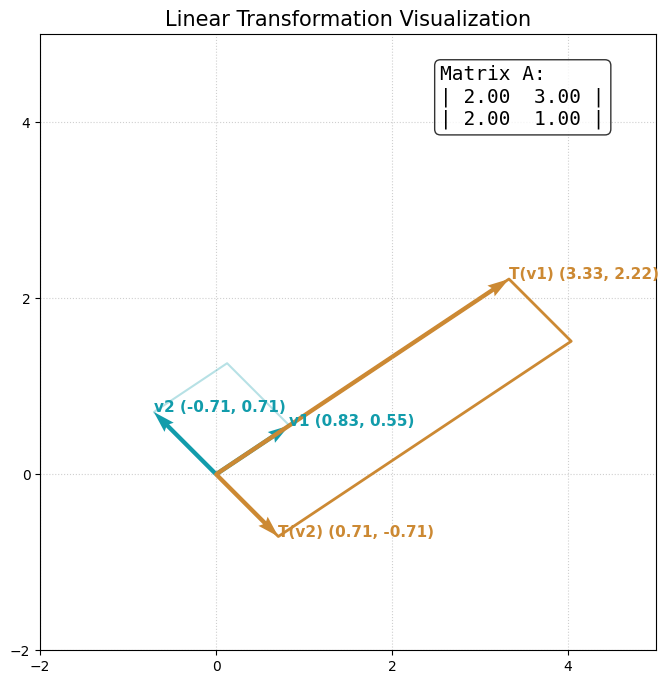

In [25]:
plot_transformation(A, A_eig[1][:,0].reshape(-1, 1), A_eig[1][:,1].reshape(-1, 1))

## **You can see that now that this linear transformation can be interpreted as a stretch in the direction of the eigenvector $v_1$ and change of the direction for the vector $v_2$.**